In [1]:
# import pandas as pd

# df_features = pd.read_csv("/kaggle/input/ai-text-detection/features_matrix.csv")
# df_features.head(20)


In [2]:
!pip install numpy==1.26.4 --force-reinstall
!pip install transformers==4.40.2 accelerate==0.30.1 peft==0.11.1
!pip install datasets evaluate


  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pand

In [3]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, ClassLabel
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
import torch.nn as nn
import evaluate


2025-12-03 01:45:46.172753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764726346.198606     315 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764726346.206385     315 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
from datasets import load_dataset

dataset = load_dataset("srikanthgali/ai-text-detection-pile-cleaned")

df_text = dataset["train"].to_pandas()
df_text = df_text.reset_index().rename(columns={"index": "original_text_idx"})


In [5]:
df_feat = pd.read_csv("/kaggle/input/ai-text-detection/features_matrix.csv")


In [6]:
len(df_feat)


290888

In [12]:
df_merged = df_text.merge(df_feat, on="original_text_idx", how="inner")
len(df_merged)


290888

In [14]:
df_merged["labels"] = df_merged["label_text"].astype(int)


In [15]:
feature_cols = [
    "perplexity",
    "burstiness",
    "flesch_score",
    "grade_level",
    "word_count",
    "naturalness_score",
]


In [16]:
df_sampled = (
    df_merged.groupby("labels")
      .apply(lambda x: x.sample(min(20000, len(x)), random_state=42))
      .reset_index(drop=True)
)


/tmp/ipykernel_315/645461535.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(20000, len(x)), random_state=42))


In [17]:
df_train, df_test = train_test_split(
    df_sampled,
    test_size=0.2,
    stratify=df_sampled["labels"],
    random_state=42
)


In [18]:
train_ds = Dataset.from_pandas(df_train)
test_ds  = Dataset.from_pandas(df_test)

class_label = ClassLabel(names=["human", "ai"])
train_ds = train_ds.cast_column("labels", class_label)
test_ds  = test_ds.cast_column("labels", class_label)


Casting the dataset:   0%|          | 0/32000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [19]:
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
roberta = AutoModel.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_tok = train_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)


Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [50]:
def add_features(batch):
    feats = df_sampled.loc[
        df_sampled["original_text_idx"] == batch["original_text_idx"],
        feature_cols
    ].values.astype(np.float32)[0]

    batch["features"] = feats
    return batch

train_tok = train_tok.map(add_features)
test_tok  = test_tok.map(add_features)

train_tok.set_format(type="torch")
test_tok.set_format(type="torch")


Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [22]:
class HybridClassifier(nn.Module):
    def __init__(self, roberta_model, num_features):
        super().__init__()
        self.roberta = roberta_model
        self.classifier = nn.Sequential(
            nn.Linear(768 + num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, features, labels=None):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled = outputs.last_hidden_state[:, 0]  # CLS
        concat = torch.cat([pooled, features], dim=1)
        logits = self.classifier(concat)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)
        return {"loss": loss, "logits": logits}


In [23]:
model = HybridClassifier(roberta, num_features=len(feature_cols))


In [24]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }


In [28]:
training_args = TrainingArguments(
    output_dir="./hybrid-output",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    fp16=True,
    report_to="none",
    load_best_model_at_end=True,
)


In [30]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [ ]:
trainer.train()


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.600500,0.578513,0.890125,0.888861


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [ ]:
save_dir = "./final_hybrid_model"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print("Hybrid saved to:", save_dir)


In [ ]:
# training_args.num_train_epochs = 3
# trainer.train()


In [55]:
# ====================================
# SAFE HYBRID COLLATOR (final fix)
# Handles HF batch formats
# ====================================
class HybridCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer
    
    def __call__(self, batch):
        # HuggingFace sometimes returns dicts with lists instead of list of dicts
        if isinstance(batch, dict):
            # Convert dict-of-lists → list-of-dicts
            batch = [{k: v[i] for k, v in batch.items()} for i in range(len(batch["labels"]))]

        # Now batch is guaranteed to be list[dict]
        input_ids = torch.tensor([item["input_ids"] for item in batch], dtype=torch.long)
        attention_mask = torch.tensor([item["attention_mask"] for item in batch], dtype=torch.long)
        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
        features = torch.tensor([item["features"] for item in batch], dtype=torch.float32)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "features": features
        }

collator = HybridCollator(tokenizer)


In [59]:
sample = test_tok[0]
with torch.no_grad():
    out = model(
        input_ids=sample["input_ids"].unsqueeze(0).to(device),
        attention_mask=sample["attention_mask"].unsqueeze(0).to(device),
        features=sample["features"].unsqueeze(0).to(device)
    )
print(out)
print(type(out))


{'loss': None, 'logits': tensor([[-0.3887, 11.4521]], device='cuda:0')}
<class 'dict'>


In [60]:
# ===================================================
# FINAL HYBRID PREDICTION (handles dict output)
# ===================================================
import torch
import numpy as np
from tqdm import tqdm

model.eval()
device = next(model.parameters()).device

y_true = []
y_pred = []

for i in tqdm(range(len(test_tok))):
    item = test_tok[i]

    input_ids = item["input_ids"].unsqueeze(0).to(device)
    attention_mask = item["attention_mask"].unsqueeze(0).to(device)
    features = item["features"].unsqueeze(0).to(device)
    label = int(item["labels"])

    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            features=features,
        )

    # -----------------------------
    # HANDLE dict output
    # -----------------------------
    if isinstance(output, dict):
        logits = output["logits"]
    else:
        logits = output

    pred = torch.argmax(logits, dim=1).item()

    y_true.append(label)
    y_pred.append(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


100%|██████████| 8000/8000 [02:26<00:00, 54.58it/s]


In [61]:
# list(globals().keys())


In [64]:
# print("Accuracy:", accuracy_score(y_true, y_pred))
# print("F1:", f1_score(y_true, y_pred))
# print(classification_report(y_true, y_pred))


In [63]:
# ========================================
# HYBRID MODEL METRICS
# ========================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)

print("=== Hybrid Model Evaluation ===")
print(f"Accuracy:   {acc}")
print(f"Precision:  {prec}")
print(f"Recall:     {rec}")
print(f"F1 Score:   {f1}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))


=== Hybrid Model Evaluation ===
Accuracy:   0.934875
Precision:  0.888367939272159
Recall:     0.99475
F1 Score:   0.9385540747729685

Classification Report:

              precision    recall  f1-score   support

           0     0.9940    0.8750    0.9307      4000
           1     0.8884    0.9948    0.9386      4000

    accuracy                         0.9349      8000
   macro avg     0.9412    0.9349    0.9346      8000
weighted avg     0.9412    0.9349    0.9346      8000



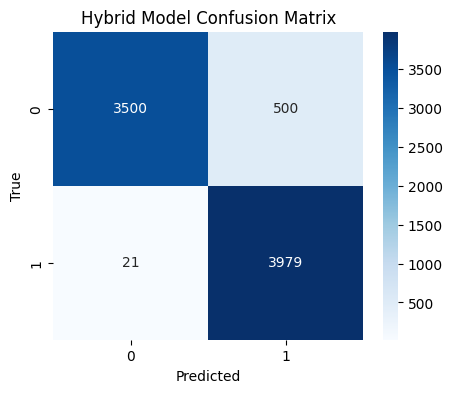

In [65]:
# ========================================
# CONFUSION MATRIX
# ========================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid Model Confusion Matrix")
plt.show()


In [66]:
# ========================================
# SAVE PREDICTIONS TO CSV
# ========================================
import pandas as pd

df_predictions = pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred
})

df_predictions.to_csv("hybrid_predictions.csv", index=False)
print("Saved hybrid_predictions.csv")


Saved hybrid_predictions.csv


In [67]:
# ========================================
# SAVE MODEL WEIGHTS
# ========================================
torch.save(model.state_dict(), "hybrid_model.pt")
print("Saved hybrid_model.pt")


Saved hybrid_model.pt


In [68]:
# ========================================
# SAVE HYBRID CONFIG
# ========================================
import json

hybrid_config = {
    "num_features": len(test_tok[0]["features"]),
    "text_encoder": MODEL_NAME,   # the transformer model you used
}

with open("hybrid_config.json", "w") as f:
    json.dump(hybrid_config, f, indent=4)

print("Saved hybrid_config.json")


Saved hybrid_config.json


In [ ]:
import shutil

shutil.make_archive("hybrid_outputs", "zip", ".")


In [ ]:
# ========================================
# PREDICTION DISTRIBUTION HISTOGRAM
# ========================================
plt.figure(figsize=(6,4))
plt.hist(y_pred, bins=2, color="#9C27B0", rwidth=0.8)
plt.xticks([0,1], ["Human (0)", "AI (1)"])
plt.title("Hybrid Model Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()
